In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sashimi_c
import scipy.integrate as integrate

mdl = sashimi_c.halo_model()

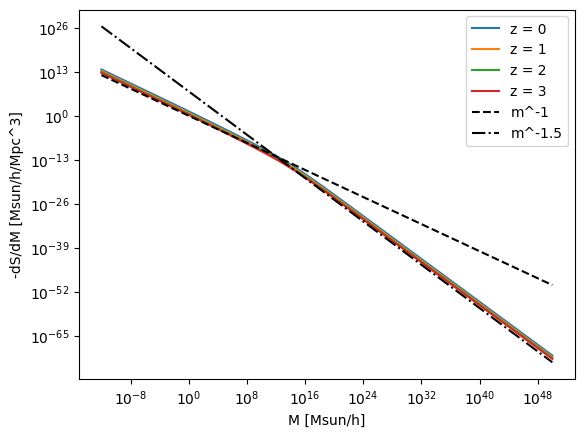

In [7]:
for z in [0, 1, 2, 3]:
    m = np.logspace(-12, 50, 100)
    dsdm = mdl.dsdm(m, z)
    dsdm = -dsdm
    plt.plot(m, dsdm, label='z = %d' % z)
plt.plot(m,m**-1, label='m^-1', color='black', linestyle='--')
plt.plot(m,1e-12*(m/1e12)**-1.6, label='m^-1.5', color='black', linestyle='-.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('M [Msun/h]')
plt.ylabel('-dS/dM [Msun/h/Mpc^3]')
plt.legend()
plt.show()

$ds/dm \propto m^{-1}$ for $m\ll 10^{12} M_{\odot}$ and $ds/dm \propto m^{-1.5}$ for $m\gg 10^{12} M_{\odot}$.

So, roughly speaking, $s(m) = \int_m^{\infty}dsdm$ is approximated as 
$$
s(m) \approx \begin{cases}
\log(m) & \text{if } m\ll 10^{12} M_{\odot} \\
m^{-0.5} & \text{if } m\gg 10^{12} M_{\odot}
\end{cases}

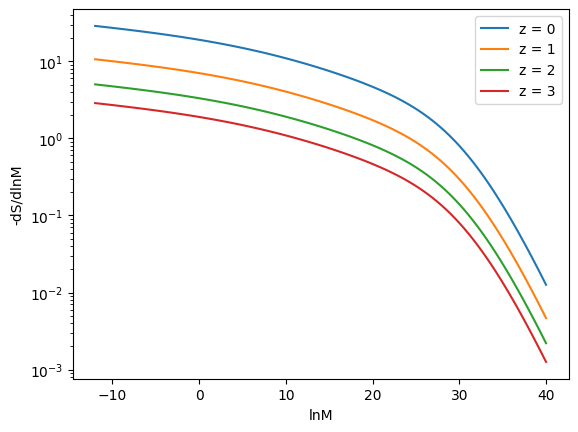

/tmp/ipykernel_1333010/431189676.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return integrate.quad(lambda lnm,z: -dsdlnm(lnm,z), lnm, np.inf, args=(z))[0]


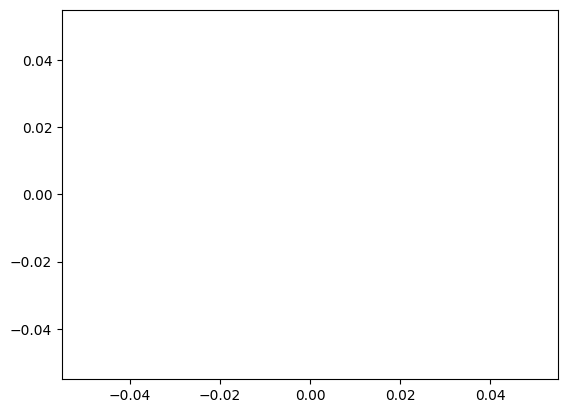

In [ ]:
def dsdlnm(lnm, z):
    m = np.exp(lnm)
    return mdl.dsdm(m, z) * m

def s(z,m):
    # integrate dsdm over mass. Note that s(M=inf) = 0 and s(M=0) = inf.
    # integrating dsdm is not stable. Instead, 
    # \int_m^\inf ds/dm dm = \int_lnm^\inf m ds/dm dlnm
    lnm = np.log(m)
    return integrate.quad(lambda lnm,z: -dsdlnm(lnm,z), lnm, np.inf, args=(z))[0]
s = np.vectorize(s)

def dlnsdlnm(lnm, z):
    m = np.exp(lnm)
    return mdl.dsdm(m, z) * m / s(z,m)

# plot dsdlnm
for z in [0, 1, 2, 3]:
    lnm = np.linspace(-12, 40, 100)
    dsdlnm_ = -dsdlnm(lnm, z)
    plt.plot(lnm, dsdlnm_, label='z = %d' % z)
# plt.plot(lnm, np.exp(lnm), label='exp(lnm)', color='black', linestyle='--')
# plt.plot(lnm, 1e-12*np.exp(1.6*lnm), label='exp(1.6lnm)', color='black', linestyle='-.')
plt.xlabel('lnM')
plt.ylabel('-dS/dlnM')
plt.yscale('log')
plt.legend()
plt.show()


z = 0
m = np.logspace(10, 15, 100)
plt.plot(m, s(z,m), label='z = %d' % z)
# plt.xscale('log')
# plt.yscale('log')
plt.show()
    